In [1]:
import typing as t

import numpy as np
import polars as pl

from src.config.constants import Product
from src.research import (
    ADFResult,
    AnalysisResult,
    MeanReversionTestResults,
    OrderbookAnalysisResult,
    Plots,
    SubsampledRegressionResults,
    TradesAnalysisResult,
    display_plots,
    run_analysis,
    run_mean_reversion_test,
)

HYDROGEL_PACK: t.Final[Product] = Product.HYDROGEL_PACK
ROUND: t.Final[int] = 3
DAY: t.Final[int] = 0

analysis_result: t.Final[AnalysisResult] = run_analysis(ROUND, DAY, HYDROGEL_PACK)
orderbook_analysis: t.Final[OrderbookAnalysisResult] = (
    analysis_result.orderbook_analysis_result
)
trades_analysis: t.Final[TradesAnalysisResult] = analysis_result.trades_analysis_result
plots: t.Final[Plots] = analysis_result.plots

# Orderbook Analysis

In [2]:
orderbook_data: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_data
orderbook_features_data: t.Final[pl.DataFrame] = (
    orderbook_analysis.orderbook_features_data
)
orderbook_stats: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_stats
orderbook_corrs: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_corrs

orderbook_data

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,midprice_dev,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,i64
0,9992,15,9990,30,null,null,10008,15,10010,30,null,null,10000.0,16,0.0,9.0379,null,0.0,10000.0,0.0,30
100,9992,13,9990,30,null,null,10008,13,10011,30,null,null,10000.0,16,0.0,9.0379,0.0,0.0003,10000.0,0.0,26
200,9995,13,9992,21,null,null,10011,13,10013,21,null,null,10003.0,16,0.0,12.0379,0.0003,-0.0001,10003.0,0.0,26
300,9994,11,9992,23,null,null,10010,11,10013,23,null,null,10002.0,16,0.0,11.0379,-0.0001,0.0001,10002.0,0.0,22
400,9995,13,9993,23,null,null,10011,13,10014,23,null,null,10003.0,16,0.0,12.0379,0.0001,-0.0003,10003.0,0.0,26
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,9951,13,9949,28,null,null,9967,13,9970,28,null,null,9959.0,16,0.0,-31.9621,-0.000402,0.0001,9959.0,0.0,26
999600,9952,14,9949,27,null,null,9968,14,9970,27,null,null,9960.0,16,0.0,-30.9621,0.0001,-0.000402,9960.0,0.0,28
999700,9948,11,9946,24,null,null,9964,11,9966,24,null,null,9956.0,16,0.0,-34.9621,-0.000402,0.000201,9956.0,0.0,22


In [3]:
orderbook_features_data

timestamp,mid_price,midprice_dev,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,f64,f64,i64,f64,f64,f64,f64,f64,i64
0,10000.0,9.0379,16,0.0,null,0.0,10000.0,0.0,30
100,10000.0,9.0379,16,0.0,0.0,0.0003,10000.0,0.0,26
200,10003.0,12.0379,16,0.0,0.0003,-0.0001,10003.0,0.0,26
300,10002.0,11.0379,16,0.0,-0.0001,0.0001,10002.0,0.0,22
400,10003.0,12.0379,16,0.0,0.0001,-0.0003,10003.0,0.0,26
…,…,…,…,…,…,…,…,…,…
999500,9959.0,-31.9621,16,0.0,-0.000402,0.0001,9959.0,0.0,26
999600,9960.0,-30.9621,16,0.0,0.0001,-0.000402,9960.0,0.0,28
999700,9956.0,-34.9621,16,0.0,-0.000402,0.000201,9956.0,0.0,22


In [4]:
orderbook_stats

statistic,mid_price,midprice_dev,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",10000.0,10000.0,10000.0,10000.0,9999.0,9999.0,10000.0,10000.0,10000.0
"""null_count""",0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
"""mean""",9990.9621,-6.4611e-13,15.701,-0.000255,-4.2093e-7,-4.2093e-7,9990.963032,0.000932,24.7306
"""std""",25.328358,25.328358,1.512491,0.016935,0.000219,0.000219,25.324786,0.230993,3.519696
"""min""",9928.0,-62.9621,7.0,-0.142857,-0.001151,-0.001151,9928.0,-2.5,14.0
"""25%""",9972.0,-18.9621,16.0,0.0,-0.0001,-0.0001,9972.0,0.0,22.0
"""50%""",9991.0,0.0379,16.0,0.0,0.0,0.0,9991.0,0.0,24.0
"""75%""",10009.0,18.0379,16.0,0.0,0.000101,0.000101,10009.0,0.0,28.0
"""max""",10071.0,80.0379,17.0,0.142857,0.000954,0.000954,10071.0,2.222222,30.0


In [5]:
orderbook_corrs

imb_corr,micro_corr
f64,f64
-0.327737,0.298284


# Trades Analysis

In [6]:
trades_data: t.Final[pl.DataFrame] = trades_analysis.trades_data
time_interval_stats: t.Final[pl.DataFrame] = trades_analysis.time_interval_stats
quantities_stats: t.Final[pl.DataFrame] = trades_analysis.quantities_stats
order_side_stats: t.Final[pl.DataFrame] = trades_analysis.order_side_stats
trade_price_streaks_stats: t.Final[pl.DataFrame] = (
    trades_analysis.trade_price_streaks_stats
)

trades_data

timestamp,price,quantity,best_bid,best_ask,mid_price,time_since_prev_trade,time_until_next_trade,mid_price_dev,side_heur
i64,f64,i64,i64,i64,f64,i64,i64,f64,str
8000,10018.0,6,10010,10018,10014.0,null,2100,4.0,"""BUY_ORDER"""
10100,10014.0,5,9998,10014,10006.0,2100,5200,8.0,"""BUY_ORDER"""
15300,10026.0,3,10009,10026,10017.5,5200,400,8.5,"""BUY_ORDER"""
15700,10009.0,2,10009,10025,10017.0,400,700,-8.0,"""SELL_ORDER"""
16400,10009.0,4,10009,10025,10017.0,700,3900,-8.0,"""SELL_ORDER"""
…,…,…,…,…,…,…,…,…,…
977200,10021.0,5,10005,10021,10013.0,400,3200,8.0,"""BUY_ORDER"""
980400,9996.0,2,9996,10012,10004.0,3200,10000,-8.0,"""SELL_ORDER"""
990400,9988.0,4,9988,10004,9996.0,10000,6600,-8.0,"""SELL_ORDER"""


In [7]:
time_interval_stats

time_since_prev_mean,time_since_prev_var,time_since_prev_std,time_until_next_mean,time_until_next_var,time_until_next_std
f64,f64,f64,f64,f64,f64
3070.897833,9.0744e6,3012.369138,3070.897833,9.0744e6,3012.369138


In [8]:
quantities_stats

qty_mean,qty_median,qty_mode,qty_var,qty_std
f64,f64,i64,f64,f64
4.16358,4.0,5,1.877183,1.370103


In [9]:
order_side_stats

total_orders,buy_orders,buy_order_rate,sell_orders,sell_order_rate
i64,i64,f64,i64,f64
324,170,0.524691,154,0.475309


In [10]:
trade_price_streaks_stats

price,streak_length
f64,u32
9965.0,1
9999.0,1
10006.0,1
9977.0,1
10012.0,1
…,…
9995.0,1
10015.0,1
9990.0,1


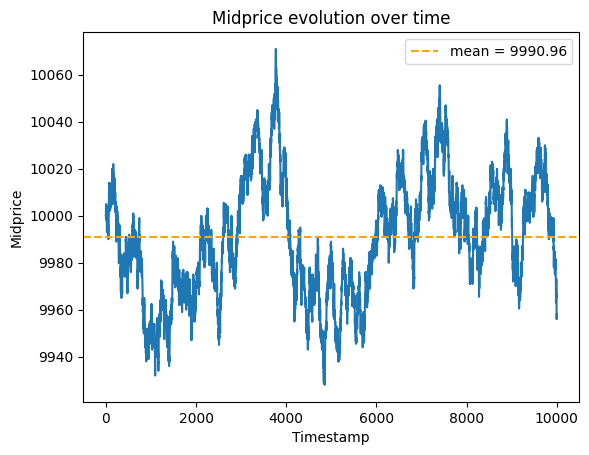

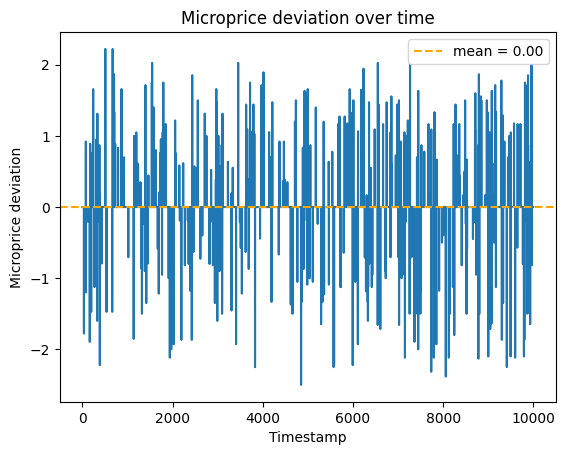

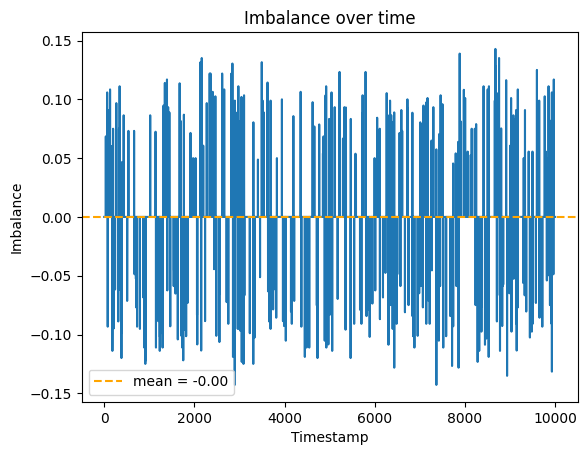

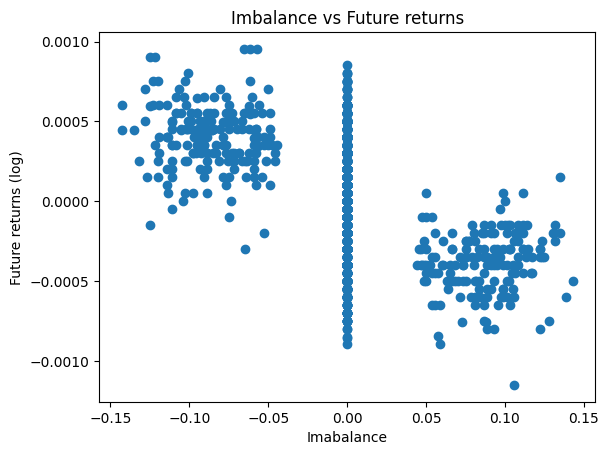

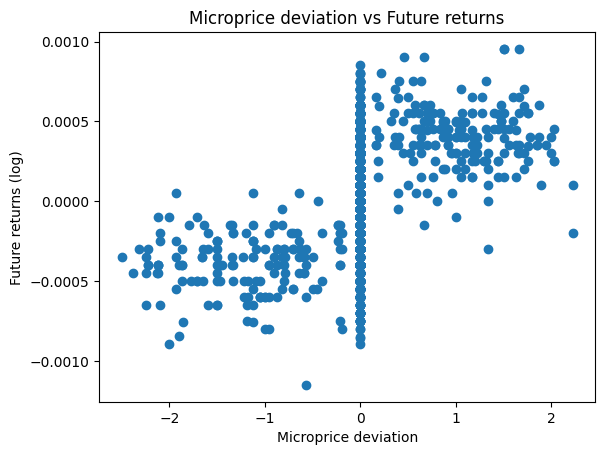

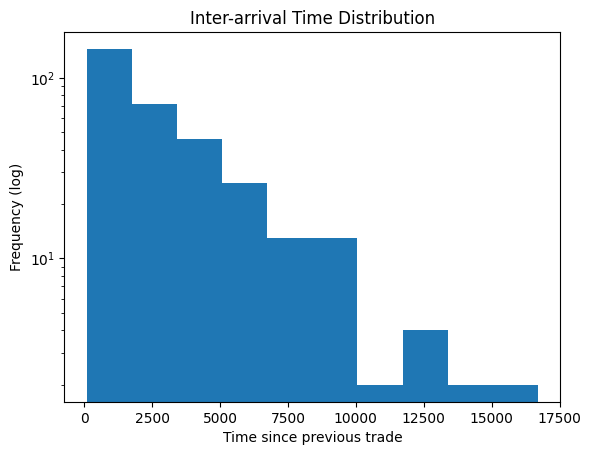

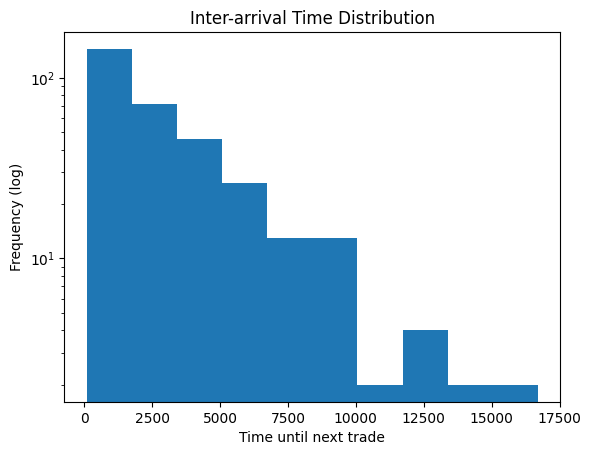

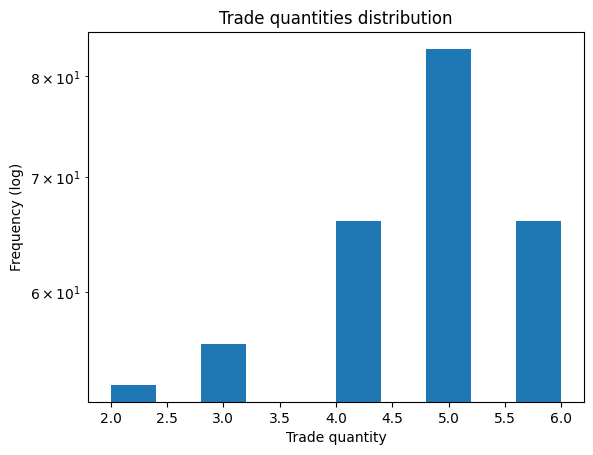

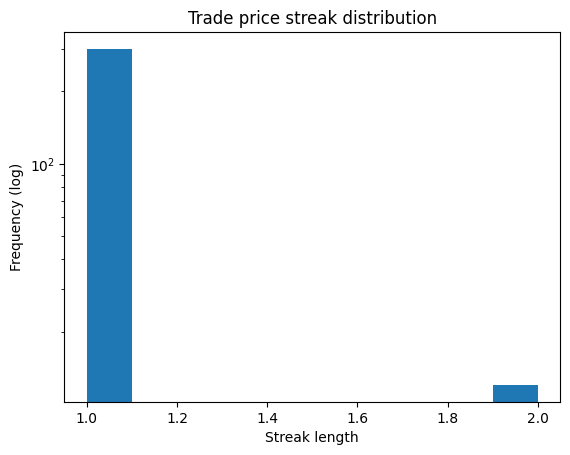

In [11]:
display_plots(plots)

# Mean Reversion Analysis

In [12]:
mean_reversion_results: t.Final[MeanReversionTestResults] = run_mean_reversion_test(
    orderbook_features_data, "mid_price"
)

regression_results: t.Final[SubsampledRegressionResults] = (
    mean_reversion_results.regression_results
)
adf_result: t.Final[ADFResult] = mean_reversion_results.adf_result
hurst_exponents: t.Final[tuple[np.float64, np.float64, np.float64]] = (
    mean_reversion_results.hurst_exponents
)

In [13]:
regression_results.print_summary()


lag_none
midprice (0 skips) is showing signs of mean reversion

lag_5
midprice (5 skips) is showing signs of mean reversion

lag_10
midprice (10 skips) is showing signs of mean reversion


In [14]:
adf_result

ADFResult(feature='mid_price', p_val=0.006438719227671722)

In [15]:
hurst_exponents

(np.float64(0.43534920913792297),
 np.float64(0.41071570350108244),
 np.float64(0.4085250222284858))